In [1]:
import pandas as pd 
df = pd.read_csv("../data/Sample - Superstore.csv")
df.head() 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [2]:
df.info()
print("Rows and Columns:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quanti

In [3]:
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64
Duplicate Rows: 504


In [4]:
df = df.drop_duplicates()
df = df.dropna()
print("Dataset Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (9983, 21)
Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicate Rows: 0


In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
print(df.dtypes)


Row ID                   object
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                float64
Discount                float64
Profit                  float64
dtype: object


In [7]:
df.to_csv("../data/cleaned_superstore.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

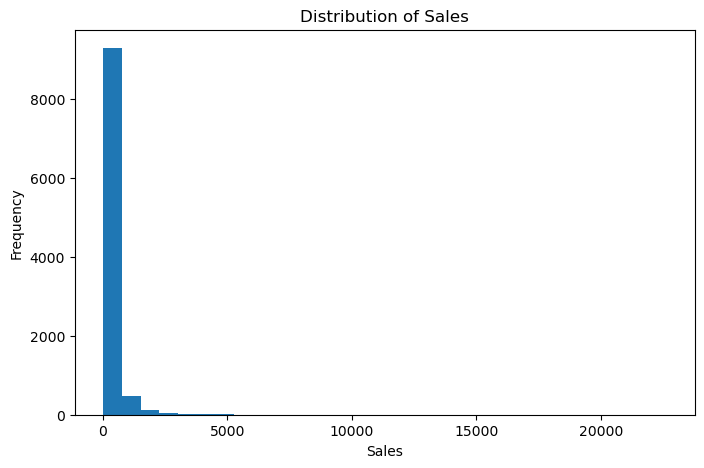

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

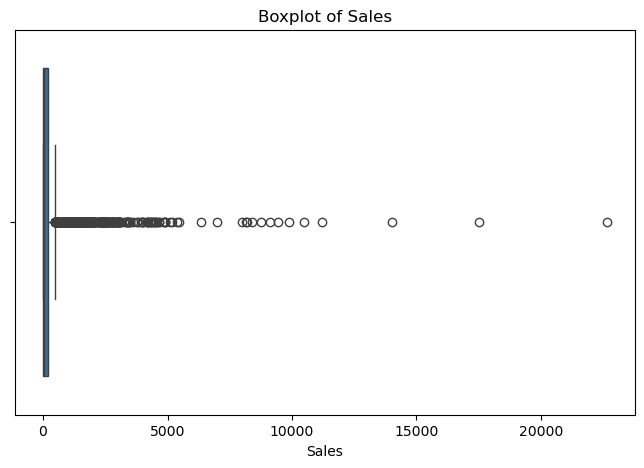

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sales"])
plt.title("Boxplot of Sales")
plt.show()


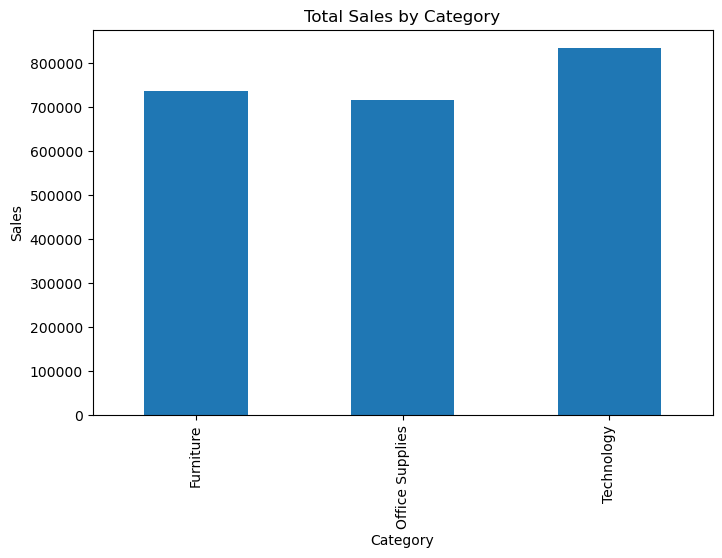

In [13]:
category_sales = df.groupby("Category")["Sales"].sum()
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

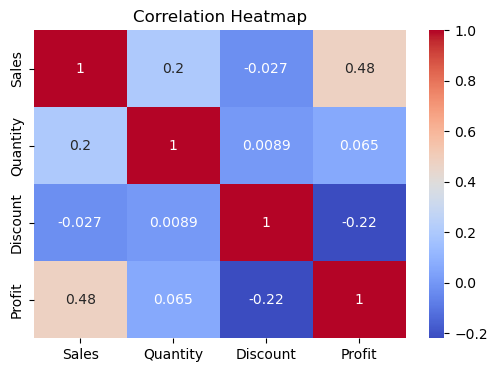

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["Sales","Quantity","Discount","Profit"]].corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

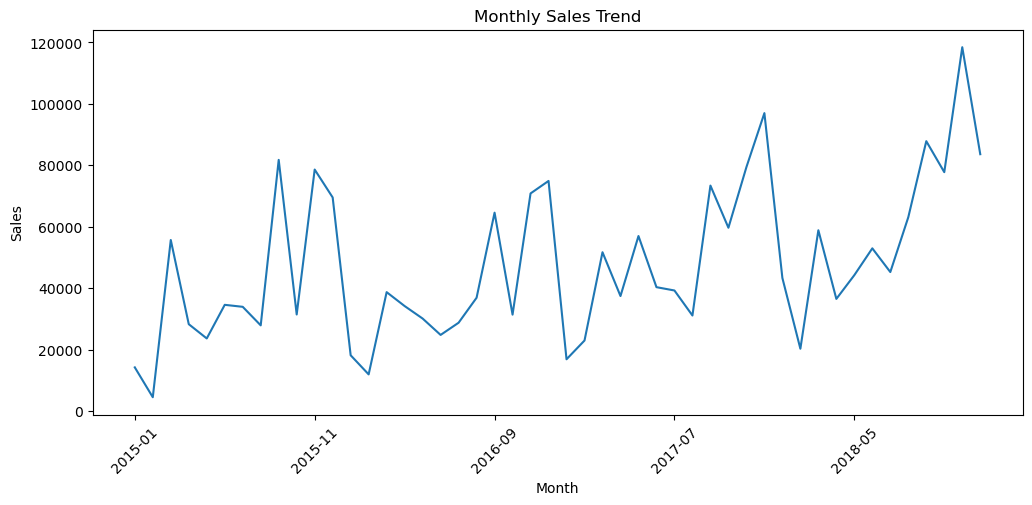

In [15]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("Month")["Sales"].sum()
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [ ]:
KEY INSIGHTS
1. SALES DISTRIBUTION (HISTOGRAM) - Most sales transaction are of low value. A few transactions have very high sales, making the distribution right-skewed.
2. SALES BOXPLOT - There are many outliers in the Sales column. A small number of orders have exceptionally high sales compared to the rest.
3. TOTAL SALES BY CATEGORY - Technology has the highest total sales. Furniture is the second highest. Office Supplies has the lowest sales among the three categories.
4. CORERELATION HEATMAP - Sales and Profit show a moderate positive correlation(~0.48). Discount and Profit have a negative correlation(~-0.22), suggesting higher discounts are associated with lower profits.
5. MONTHLY SALES TREND - Monthly sales fluctuate over time. There is an overall upward trend toward the later months. Some months show sharp peaks, indicating seasonal or high-demand periods.

In [18]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 *IQR
upper = Q3 + 1.5 *IQR

df_no_outliers = df[(df["Sales"] >= lower) & (df["Sales"] <= upper)]
print ("Original Shape:", df.shape)
print ("Shape after removing outliers:", df_no_outliers.shape)

Original Shape: (9983, 22)
Shape after removing outliers: (8821, 22)


In [19]:
df_no_outliers.to_csv("../data/cleaned_superstore_no_outliers.csv", index=False)
print("Dataset without outliers saved successfully!")

Dataset without outliers saved successfully!
